# Annotating the gold set

This notebook is where the 30 figures of the gold set are annotated by hand. The figures were drawn by `sample_gold_set.ipynb`, which saved each image to `gold_set/images/` and started an annotation file for it in `gold_set/annotations/`. Each file already holds the article details and the caption, and this notebook fills in the rest.

Four things are recorded for every figure.

1. **Figure type**, picked from a short list.
2. **Image text**, meaning all the printed text that can be read in the image, one printed line per line and panel by panel. The OCR models are scored against it.
3. **Entities**, the biomedical names that appear in the caption or in the image text, one per line written as `text | type`. The NER models are scored against them.
4. **Notes** on anything unusual, such as text too small to read.

The rules for each field, with examples, are in `gold_set/guidelines.md`. Read them before starting.

A figure counts as finished once **done** is ticked. The evaluation notebook scores only finished figures, so the set can be annotated over several sittings, and the results always say how many figures they cover.

In [6]:
import html
import json
from pathlib import Path

import ipywidgets as widgets
import pandas as pd
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
GOLD_DIR = ROOT / 'gold_set'
IMAGE_DIR = GOLD_DIR / 'images'
ANNOTATION_DIR = GOLD_DIR / 'annotations'

# the figure list and the record of how it was drawn, both written by sample_gold_set.ipynb
sample = json.loads((GOLD_DIR / 'sample.json').read_text(encoding='utf-8'))
FIGURES = {f['key']: f for f in sample['figures']}
KEYS = list(FIGURES)

FIGURE_TYPES = ['plot', 'micrograph', 'blot_or_gel', 'diagram', 'mixed', 'other']
ENTITY_TYPES = ['gene_or_protein', 'chemical', 'disease', 'organism', 'cell_or_tissue', 'technique', 'other']


def load(key):
    """Read the annotation file of one figure."""
    return json.loads((ANNOTATION_DIR / f'{key}.json').read_text(encoding='utf-8'))


def write(annotation):
    """Write an annotation file back in the same layout the sampling notebook used."""
    path = ANNOTATION_DIR / f"{annotation['key']}.json"
    path.write_text(json.dumps(annotation, indent=2, ensure_ascii=False) + '\n', encoding='utf-8')


print(f'{len(KEYS)} figures, annotation files in {ANNOTATION_DIR.relative_to(ROOT)}/')

30 figures, annotation files in gold_set/annotations/


## 1. Where the figures come from

The figures come from the May 2026 bioRxiv dump. `sample_gold_set.ipynb` kept the Cell Biology preprints released under CC BY 4.0 or CC0 1.0, took the latest version of each, and then drew 30 preprints with a fixed seed and one main figure from each. The chart is the funnel it saved, and the table lists the 30 figures in the order the form shows them. The authors of every figure are credited in `gold_set/attribution.md`.

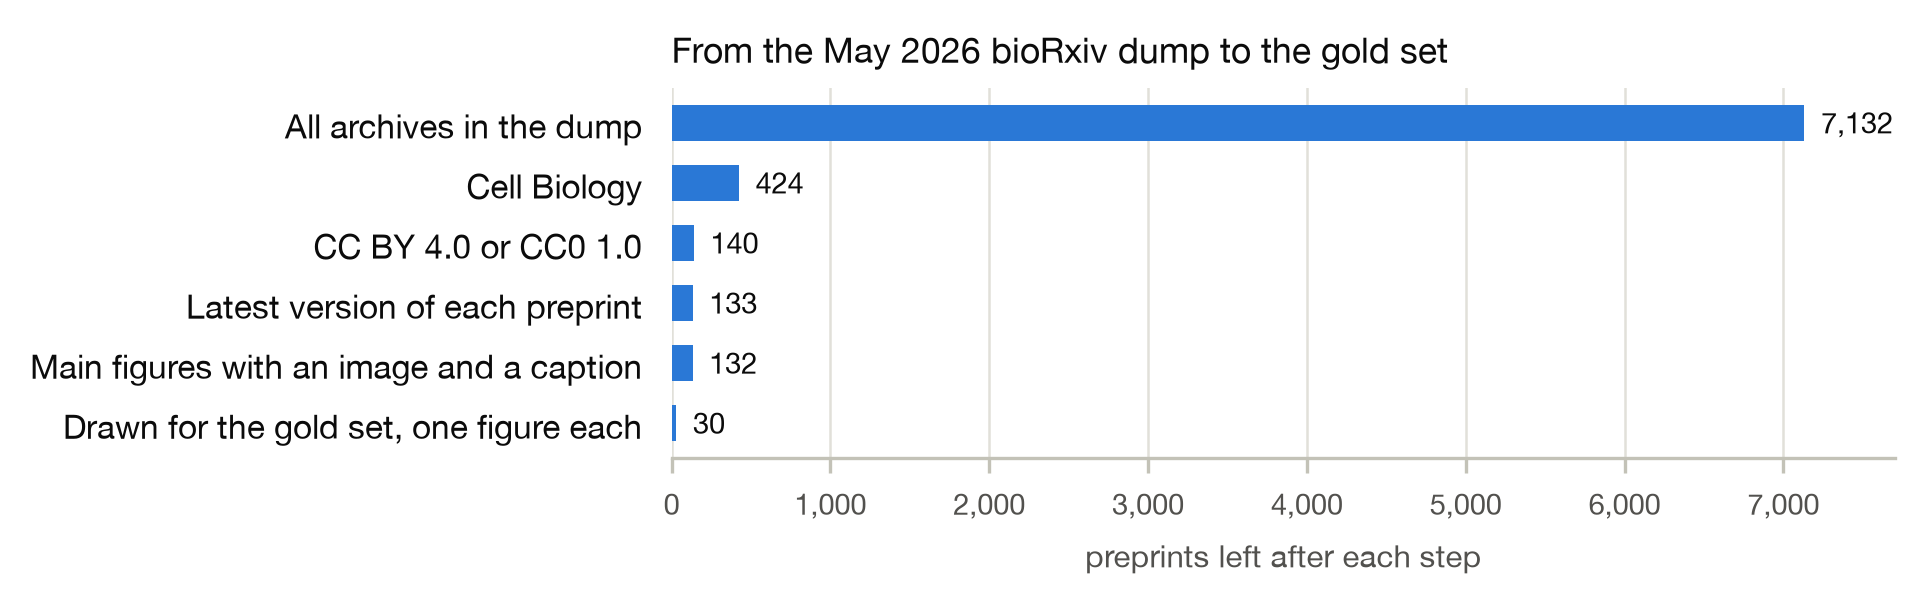

bioRxiv monthly dump, May 2026, 7,132 archives, fingerprint 826c2a14b1571f6e4b7dcd78585321aee0512f1a
Cell Biology, CC BY 4.0 or CC0 1.0, seed 20260928


,key,figure_label,authors,licence,doi
1,619578v3_fig3,Figure 3.,Tittelmeier et al.,CC BY 4.0,10.1101/2024.10.24.619578
2,628646v3_fig2,Figure 2.,Edwards et al.,CC BY 4.0,10.1101/2024.12.17.628646
3,638155v5_fig1,Fig 1.,Iuchi and Paulo,CC BY 4.0,10.1101/2025.02.13.638155
4,645038v6_fig5,Figure 5.,Fuller et al.,CC BY 4.0,10.1101/2025.03.24.645038
5,667258v2_fig11,Fig 11:,Same-Majandeh et al.,CC BY 4.0,10.1101/2025.07.28.667258
6,716888v2_fig2,Figure 2:,Versluis and Insall,CC BY 4.0,10.64898/2026.04.07.716888
7,719914v1_fig2,Figure 2:,Fröbel et al.,CC BY 4.0,10.64898/2026.04.30.719914
8,721503v1_fig3,Figure 3:,Buglak et al.,CC0 1.0,10.64898/2026.04.28.721503
9,722203v1_fig7,Figure 7.,Asaro et al.,CC BY 4.0,10.64898/2026.05.02.722203
10,722309v1_fig3,Figure 3.,Wu et al.,CC BY 4.0,10.64898/2026.05.01.722309


In [7]:
display(Image(filename=str(GOLD_DIR / 'sampling_funnel.png'), width=720))
print(f"{sample['corpus']}, {sample['archives']:,} archives, fingerprint {sample['fingerprint_sha1']}")
print(f"{sample['subject']}, {' or '.join(sample['licences'])}, seed {sample['seed']}")

figure_table = pd.DataFrame(sample['figures'], index=range(1, len(KEYS) + 1))
figure_table[['key', 'figure_label', 'authors', 'licence', 'doi']]

## 2. Checks made on saving

Saving runs a few checks. A figure can only be marked done when it has a figure type and every entity has some text, a type from the list, and appears word for word in the caption or in the image text. Capital letters and extra spaces are ignored in that comparison, the same way the evaluation ignores them. The same name listed twice is also flagged. When a check fails the figure is still saved, but it stays not done and the problems are listed under the Save button.

The image text itself is not checked, because some figures have no printed text at all.

In [8]:
def norm(text):
    """Lower case with the whitespace collapsed, the same comparison the evaluation uses."""
    return ' '.join(text.lower().split())


def clean_text(text):
    """Tidy a text box: no spaces at the ends of lines and no empty lines at the start or end."""
    return '\n'.join(line.rstrip() for line in text.strip().splitlines())


def count_lines(text):
    return sum(1 for line in text.splitlines() if line.strip())


def parse_entities(text):
    """Turn the entity box, one 'text | type' per line, into a list of dicts."""
    entities = []
    for line in text.splitlines():
        if not line.strip():
            continue
        name, bar, kind = line.rpartition('|')
        if not bar:
            name, kind = line, ''
        entities.append({'text': name.strip(), 'type': kind.strip()})
    return entities


def format_entities(entities):
    """The reverse of parse_entities, used to put saved entities back in the box."""
    return '\n'.join(f"{e['text']} | {e['type']}" for e in entities)


def problems(annotation):
    """Everything that stops a figure from being marked done. An empty list means it is fine."""
    gold = annotation['gold']
    found = []
    if gold['figure_type'] not in FIGURE_TYPES:
        found.append('no figure type chosen')
    source = norm(annotation['paper']['caption'] + ' ' + gold['ocr_text'])
    seen = set()
    for e in gold['entities']:
        text = norm(e['text'])
        if not text:
            found.append(f"an entity of type '{e['type']}' has no text")
            continue
        if not e['type']:
            found.append(f"{e['text']}: no type given")
        elif e['type'] not in ENTITY_TYPES:
            found.append(f"{e['text']}: '{e['type']}' is not one of the entity types")
        if text not in source:
            found.append(f"{e['text']}: not found in the caption or the image text")
        if text in seen:
            found.append(f"{e['text']}: listed twice")
        seen.add(text)
    return found

## 3. The form

Pick a figure from the list or step through the set with Previous and Next. The picture is on the left and the fields are on the right, so the image stays in view while typing. Zoom shows the picture at half or full size for small text, and the picture then scrolls inside its frame.

Save writes the fields to the figure's file, and moving to another figure saves the one on screen first. Under the form is the file exactly as it was last saved. If the form stops responding after a kernel restart, run the notebook from the top again.

In [9]:
state = {'index': 0}
ZOOM = {'fit width': None, 'half size': 0.5, 'full size': 1.0}

figure_list = widgets.Dropdown(options=[(f'{n}. {key}', n - 1) for n, key in enumerate(KEYS, start=1)],
                               description='Figure')
previous_button = widgets.Button(description='Previous')
next_button = widgets.Button(description='Next')
paper_info = widgets.HTML()

zoom = widgets.ToggleButtons(options=list(ZOOM), description='Zoom')
picture = widgets.Image(format='png', layout=widgets.Layout(flex='0 0 auto', max_width='none'))
picture_frame = widgets.Box([picture], layout=widgets.Layout(display='block', overflow='auto', max_height='900px',
                                                             border='1px solid #c3c2b7'))

figure_type = widgets.Dropdown(options=[('choose one', '')] + [(t, t) for t in FIGURE_TYPES])
ocr_text = widgets.Textarea(layout=widgets.Layout(width='100%', height='360px'))
entities = widgets.Textarea(placeholder='actin | gene_or_protein', layout=widgets.Layout(width='100%', height='220px'))
notes = widgets.Textarea(layout=widgets.Layout(width='100%', height='60px'))
done = widgets.Checkbox(description='done', indent=False)
save_button = widgets.Button(description='Save', button_style='primary')
status = widgets.HTML()
saved_title = widgets.HTML()
saved_json = widgets.Textarea(disabled=True, layout=widgets.Layout(width='100%', height='320px'))


def paper_html(annotation):
    """The article details shown above the picture."""
    p = {k: html.escape(v) for k, v in annotation['paper'].items()}
    f = FIGURES[annotation['key']]
    return (f"<div style='line-height: 1.4'>"
            f"<h3>{state['index'] + 1} of {len(KEYS)}: {p['figure_label'].rstrip('.')} of preprint {p['preprint']}</h3>"
            f"<a href='https://doi.org/{p['doi']}' target='_blank'>{p['title']}</a><br>"
            f"{p['authors']}, {p['licence']}, image {f['width']} by {f['height']} pixels"
            f"<p><b>Caption.</b> {p['caption']}</p></div>")


def form_values():
    """The figure on screen as an annotation, with the gold part read from the fields."""
    annotation = load(KEYS[state['index']])
    annotation['gold'] = {
        'figure_type': figure_type.value,
        'ocr_text': clean_text(ocr_text.value),
        'entities': parse_entities(entities.value),
        'notes': notes.value.strip(),
        'done': done.value,
    }
    return annotation


def show_saved(annotation):
    saved_title.value = f"<b>Saved file</b>, gold_set/annotations/{annotation['key']}.json"
    saved_json.value = json.dumps(annotation, indent=2, ensure_ascii=False)


def save(_=None):
    """Write the fields to the figure's file. A figure with problems is kept as not done."""
    annotation = form_values()
    gold = annotation['gold']
    found = problems(annotation)
    if found and gold['done']:
        gold['done'] = False
        done.value = False
    write(annotation)
    show_saved(annotation)
    message = (f"Saved {annotation['key']} with {count_lines(gold['ocr_text'])} lines of image text "
               f"and {len(gold['entities'])} entities, {'done' if gold['done'] else 'not done yet'}.")
    if found:
        message += '<br>To fix before it can be done:<ul>' + ''.join(f'<li>{html.escape(p)}</li>' for p in found) + '</ul>'
    status.value = f"<div style='line-height: 1.4'>{message}</div>"


def set_zoom(_=None):
    scale = ZOOM[zoom.value]
    width = FIGURES[KEYS[state['index']]]['width']
    picture.layout.width = '100%' if scale is None else f'{round(width * scale)}px'


def show_figure(index):
    """Fill the form with one figure: its article, its picture and its saved annotation."""
    state['index'] = index
    key = KEYS[index]
    annotation = load(key)
    gold = annotation['gold']
    paper_info.value = paper_html(annotation)
    picture.value = (IMAGE_DIR / f'{key}.png').read_bytes()
    set_zoom()
    figure_type.value = gold['figure_type'] if gold['figure_type'] in FIGURE_TYPES else ''
    ocr_text.value = gold['ocr_text']
    entities.value = format_entities(gold['entities'])
    notes.value = gold['notes']
    done.value = gold['done']
    show_saved(annotation)


def pick(change):
    """Moving to another figure saves the one on screen first."""
    save()
    show_figure(change['new'])


def step(offset):
    figure_list.value = min(max(state['index'] + offset, 0), len(KEYS) - 1)


figure_list.observe(pick, names='value')
previous_button.on_click(lambda _: step(-1))
next_button.on_click(lambda _: step(1))
save_button.on_click(save)
zoom.observe(set_zoom, names='value')

fields = widgets.VBox([
    widgets.HTML('<b>Figure type</b>'), figure_type,
    widgets.HTML('<b>Image text</b>, one printed line per line, panel by panel'), ocr_text,
    widgets.HTML('<b>Entities</b>, one per line as text | type'),
    widgets.HTML(f"<div style='line-height: 1.4'>Types: {', '.join(ENTITY_TYPES)}</div>"), entities,
    widgets.HTML('<b>Notes</b>'), notes,
    widgets.HBox([done, save_button]),
    status,
], layout=widgets.Layout(width='40%', padding='0 0 0 16px'))

show_figure(0)
display(widgets.VBox([
    widgets.HBox([figure_list, previous_button, next_button]),
    paper_info,
    widgets.HBox([widgets.VBox([zoom, picture_frame], layout=widgets.Layout(width='60%')), fields]),
    saved_title,
    saved_json,
]))

## 4. Progress

This table reads every annotation file again, so it can be run at any time, including at the start of a new sitting. The problems column lists what still stops a figure from being marked done.

In [10]:
rows = []
for n, key in enumerate(KEYS, start=1):
    annotation = load(key)
    gold = annotation['gold']
    rows.append({
        'n': n,
        'key': key,
        'figure type': gold['figure_type'],
        'text lines': count_lines(gold['ocr_text']),
        'entities': len(gold['entities']),
        'done': gold['done'],
        'problems': ', '.join(problems(annotation)),
    })

progress = pd.DataFrame(rows).set_index('n')
print(f"{progress['done'].sum()} of {len(progress)} figures done")
progress

30 of 30 figures done


,key,figure type,text lines,entities,done,problems
n,,,,,,
1,619578v3_fig3,mixed,113,14,True,
2,628646v3_fig2,plot,137,13,True,
3,638155v5_fig1,diagram,61,14,True,
4,645038v6_fig5,mixed,64,24,True,
5,667258v2_fig11,plot,56,4,True,
6,716888v2_fig2,mixed,69,0,True,
7,719914v1_fig2,plot,289,27,True,
8,721503v1_fig3,micrograph,53,21,True,
9,722203v1_fig7,mixed,49,9,True,
